In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rishidamarla/heart-disease-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-prediction' dataset.
Path to dataset files: /kaggle/input/heart-disease-prediction


In [ ]:
import os
print(os.listdir(path))

['Heart_Disease_Prediction.csv']


##EDA

In [ ]:
df=pd.read_csv(path+'/Heart_Disease_Prediction.csv')

In [ ]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [ ]:
df.isna().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


##Graph

<Axes: xlabel='Heart Disease', ylabel='count'>

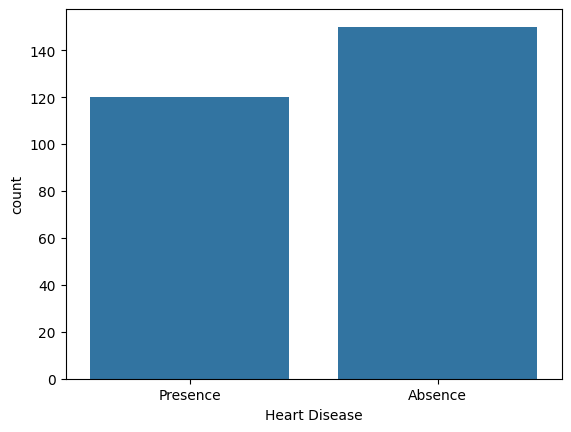

In [ ]:
sns.countplot(x='Heart Disease',data=df)

<Axes: xlabel='Heart Disease', ylabel='BP'>

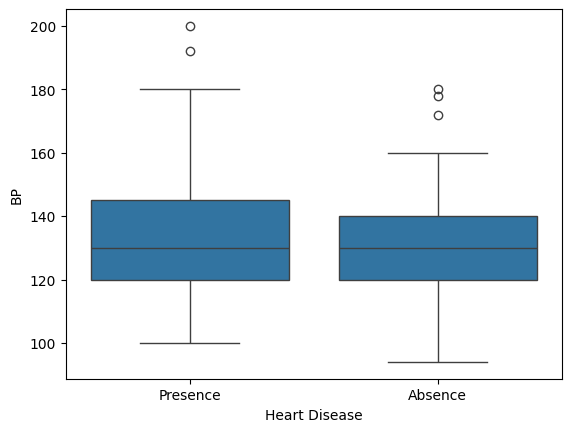

In [ ]:
sns.boxplot(x='Heart Disease',y='BP',data=df)

<Axes: >

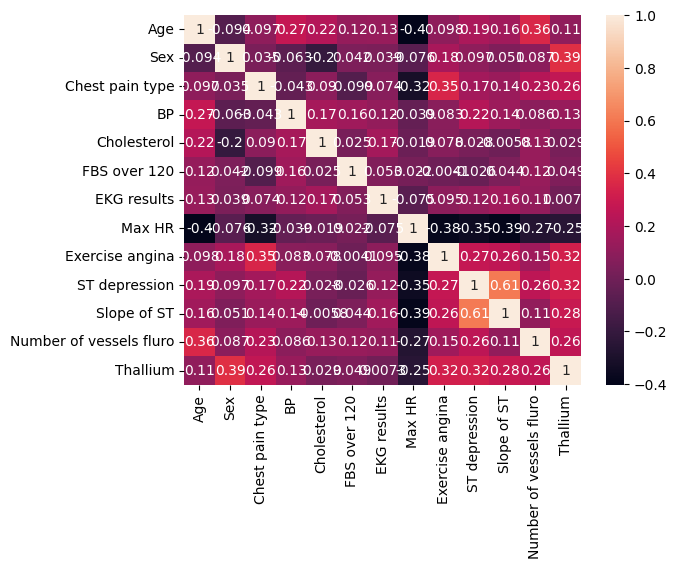

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [ ]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
df["Heart Disease"]=df["Heart Disease"].map(
    {
        "Presence":1,
        "Absence":0
    }
)

In [ ]:
df["Heart Disease"]

,Heart Disease
0,1
1,0
2,1
3,0
4,0
...,...
265,0
266,0
267,0
268,0


##X and Y

In [ ]:
X=df.drop("Heart Disease",axis=1)

In [ ]:
y=df["Heart Disease"]

##Train

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

##Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

##Model predict and accuracy

In [ ]:
y_pred=model.predict(X_test)
from sklearn.metrics import r2_score,confusion_matrix,classification_report,accuracy_score
r2=r2_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)
acc=accuracy_score(y_test,y_pred)
print(f"R2 Score : {r2}\nConfusion Matrix : \n{cm}\n\n\nClassification Report : {cr}\nAccuracy Score : {acc}")

R2 Score : -0.16883116883116855
Confusion Matrix : 
[[23 10]
 [ 5 16]]


Classification Report :               precision    recall  f1-score   support

           0       0.82      0.70      0.75        33
           1       0.62      0.76      0.68        21

    accuracy                           0.72        54
   macro avg       0.72      0.73      0.72        54
weighted avg       0.74      0.72      0.73        54

Accuracy Score : 0.7222222222222222


##Decision tree visualization

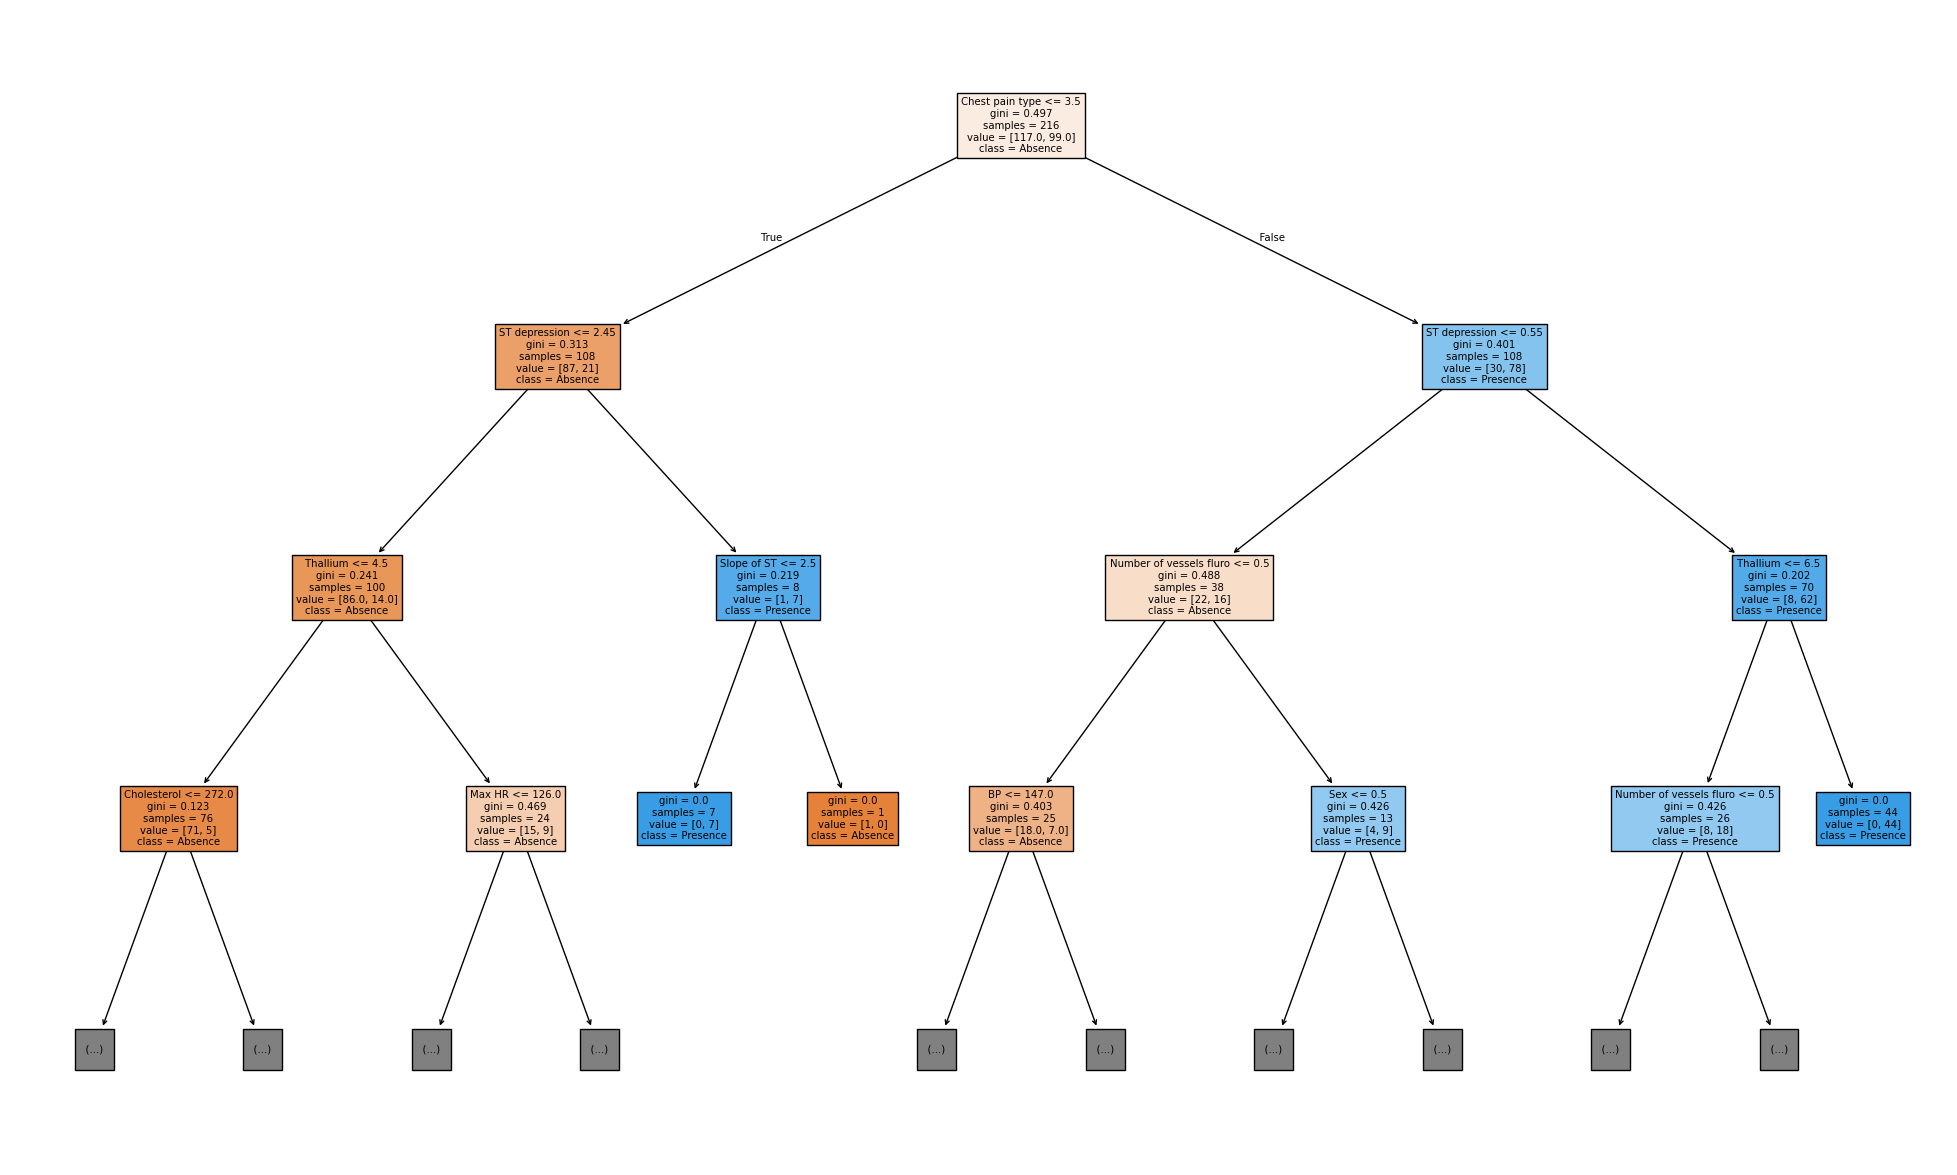

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(25,15))
plot_tree(model,max_depth=3,filled=True,feature_names=X.columns,class_names=["Absence","Presence"])
plt.show()

In [ ]:
X.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium'],
      dtype='object')

In [ ]:
X.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3


##Predict New value

In [ ]:
new_data=[[
    25,1,3,222,59,1,1,165,0,0,0,2,3
]]
predit=model.predict(new_data)
if (predit==0):
  print("Absence")
else:
  print("Presence")


Absence
